In [ ]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 7.9 MB/s eta 0:00:00


Fetching street data within 4500m of Tykistökatu 6, 20520 Turku...
Fetching the Aura River and water bodies...
Fetching locations for highlights...
 ✓ Found building shape: Tykistökatu 6, 20520 Turku
 ✓ Found building shape: Uudenmaantie 17, 20700 Turku
 ✓ Found building shape: Itäinen Pitkäkatu 38
 ✓ Found building shape: Turku University Hospital
 ✓ Found building shape: Linnankatu 65, 20100 Turku
Plotting the beautiful map...
Success! turku_wood_print_final.png has been saved and is perfectly aligned without overlaps.


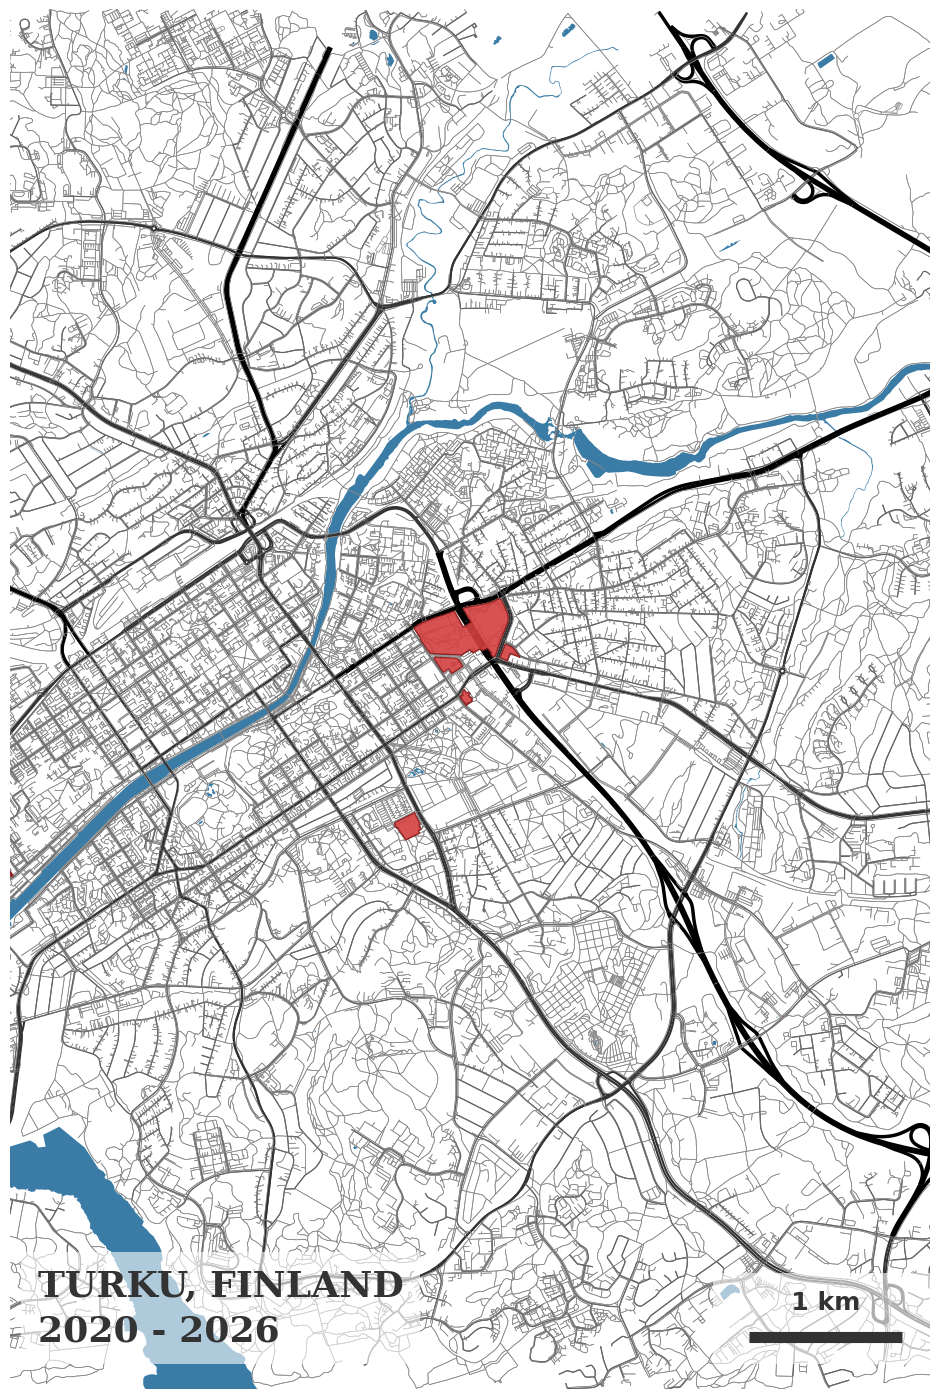

In [ ]:
import osmnx as ox
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math

center_address = "Tykistökatu 6, 20520 Turku"
fetch_radius = 4500

print(f"Fetching street data within {fetch_radius}m of {center_address}...")
G = ox.graph_from_address(center_address, dist=fetch_radius, network_type='all')

print("Fetching the Aura River and water bodies...")
water_tags = {'natural': ['water', 'bay', 'strait'], 'waterway': ['river', 'stream', 'canal']}
water = ox.features_from_address(center_address, tags=water_tags, dist=fetch_radius)

# --- HIGHLIGHTED BUILDINGS ---
buildings_to_highlight = [
    "Tykistökatu 6, 20520 Turku",
    "Uudenmaantie 17, 20700 Turku",
    "Itäinen Pitkäkatu 38",
    "Turku University Hospital",
    "Linnankatu 65, 20100 Turku"
]

print("Fetching locations for highlights...")
highlight_gdfs = []
highlight_points = []

for place in buildings_to_highlight:
    try:
        gdf = ox.geocode_to_gdf(place)
        if gdf.geometry.iloc[0].geom_type in ['Polygon', 'MultiPolygon']:
            highlight_gdfs.append(gdf)
            print(f" ✓ Found building shape: {place}")
        else:
            lat, lon = ox.geocode(place)
            highlight_points.append((lon, lat))
            print(f" ✓ Found as point: {place}")
    except Exception as e:
        try:
            lat, lon = ox.geocode(place)
            highlight_points.append((lon, lat))
            print(f" ✓ Found as point: {place}")
        except Exception as e2:
            print(f" ✕ Could not find: {place}")

# --- VISUAL HIERARCHY: WOOD-OPTIMIZED COLORS ---
edge_linewidths = []
edge_colors = []

for _, _, _, data in G.edges(keys=True, data=True):
    highway = data.get('highway', '')
    if isinstance(highway, list): highway = highway[0]

    if highway in ['motorway', 'motorway_link', 'trunk', 'trunk_link']:
        edge_linewidths.append(2.5)
        edge_colors.append('#000000')
    elif highway in ['primary', 'primary_link', 'secondary', 'secondary_link']:
        edge_linewidths.append(1.5)
        edge_colors.append('#333333')
    elif highway in ['tertiary', 'tertiary_link', 'residential']:
        edge_linewidths.append(0.8)
        edge_colors.append('#666666')
    else:
        edge_linewidths.append(0.5)
        edge_colors.append('#888888')

print("Plotting the beautiful map...")

# --- CROPPED AXES PLOTTING ---
fig = plt.figure(figsize=(10, 15))
ax = fig.add_axes([0.04, 0.0266, 0.92, 0.9466])

ox.plot_graph(
    G,
    ax=ax,
    node_size=0,
    edge_color=edge_colors,
    edge_linewidth=edge_linewidths,
    bgcolor='#FFFFFF',
    show=False,
    close=False
)

# --- ADDING WATER ---
if not water.empty:
    water.plot(ax=ax, facecolor='#3A7CA5', edgecolor='none', zorder=0)

# --- ADDING THE RED BUILDINGS & POINTS ---
for gdf in highlight_gdfs:
    gdf.plot(ax=ax, facecolor='#D33F3F', edgecolor='#8A1C1C', linewidth=1, alpha=0.9, zorder=5)

if highlight_points:
    lons, lats = zip(*highlight_points)
    ax.scatter(lons, lats, c='#D33F3F', edgecolor='#8A1C1C', s=150, zorder=6, alpha=0.9)

# --- THE PERFECT CROP ---
lat, lon = ox.geocode(center_address)
earth_radius = 6371000
delta_lat = (4500 / earth_radius) * (180 / math.pi)
delta_lon = (3000 / (earth_radius * math.cos(math.radians(lat)))) * (180 / math.pi)
ax.set_ylim(lat - delta_lat, lat + delta_lat)
ax.set_xlim(lon - delta_lon, lon + delta_lon)

# --- TURNING THE AXIS INTO THE BORDER ---
ax.axis('on')
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
    spine.set_linewidth(3.0)
    spine.set_zorder(10)

# --- TYPOGRAPHY (ALIGNED TO AXES) ---
ax.text(0.03, 0.03, "TURKU, FINLAND\n2020 - 2026",
         transform=ax.transAxes,
         fontsize=26,
         fontname='serif',
         ha='left',
         va='bottom',
         color='#333333',
         weight='bold',
         linespacing=1.4,
         bbox=dict(facecolor='#FFFFFF', edgecolor='none', alpha=0.6, pad=12),
         zorder=11)

# --- SCALE BAR (FIXED ALIGNMENT) ---
bar_length = 1000 / 6000
bar_end_x = 0.97
bar_start_x = bar_end_x - bar_length
bar_y = 0.03

# 1. Draw the text AND the frosted box
# By removing the squished linespacing and adding a space to the bottom line ("\n "),
# the text moves up and creates a clean gap for the bar below.
ax.text(bar_start_x + (bar_length / 2), bar_y,
        "       1 km       \n ",
        transform=ax.transAxes,
        fontsize=18,
        fontname='sans-serif',
        ha='center',
        va='bottom',
        color='#333333',
        weight='bold',
        linespacing=1.5,        # FIXED: This pushes the "1 km" safely above the bar
        bbox=dict(facecolor='#FFFFFF', edgecolor='none', alpha=0.6, pad=12),
        zorder=11)

# 2. Draw the thick black bar INSIDE the empty bottom half of the frosted box
ax.plot([bar_start_x, bar_end_x], [bar_y + 0.008, bar_y + 0.008],  # FIXED: Dropped down slightly
        transform=ax.transAxes,
        color='#333333',
        linewidth=8,
        solid_capstyle='butt',
        zorder=12)

# --- SAVING EXACTLY FOR THE PRINTER ---
filename = "turku_wood_print_final.png"
fig.savefig(filename, dpi=300, transparent=True)

print(f"Success! {filename} has been saved and is perfectly aligned without overlaps.")